# Prefix trade-off

Sized for a half-width LaTeX figure. Numbers indicate prefix lengths; full steering, Prompt, and Unsteered are identified by the legend. PDF output is saved under `figs/`.

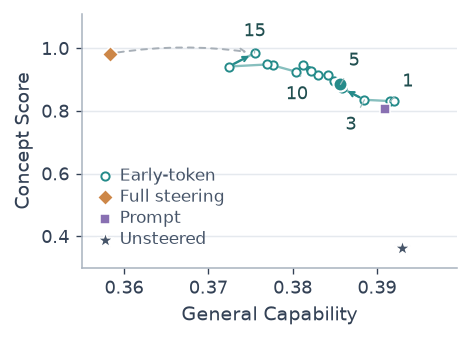

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from io import StringIO
from pathlib import Path

CSV_DATA = """series,prefix_len,general_capability,concept_score
Early-token,1,0.391573,0.8305
Early-token,2,0.391981,0.831017
Early-token,3,0.388518,0.835593
Early-token,4,0.385871,0.87229
Early-token,5,0.385667,0.884746
Early-token,6,0.384852,0.894407
Early-token,7,0.384241,0.915085
Early-token,8,0.383019,0.915085
Early-token,9,0.382205,0.928305
Early-token,10,0.381186,0.945085
Early-token,11,0.380372,0.925424
Early-token,12,0.377724,0.945085
Early-token,13,0.376909,0.948305
Early-token,14,0.372429,0.941864
Early-token,15,0.375484,0.984746
Full steering,,0.358376,0.98305
Unsteered,,0.392999,0.362712
Prompt,,0.390999,0.80732712
"""

df = pd.read_csv(StringIO(CSV_DATA))
early = df[df["series"] == "Early-token"].copy().sort_values("prefix_len")
all_pt = df[df["series"] == "Full steering"].iloc[0]
un_pt = df[df["series"] == "Unsteered"].iloc[0]
prompt_pt = df[df["series"] == "Prompt"].iloc[0]

# A single linear-axis view with distinct, muted method colors.
COLORS = {"early": "#258B8A", "all": "#CD8748", "prompt": "#8970B2", "base": "#475569"}
fig, ax = plt.subplots(figsize=(3.35, 2.45), dpi=140)
fig.subplots_adjust(left=0.18, right=0.98, bottom=0.22, top=0.96)

xy = early[["general_capability", "concept_score"]].to_numpy()
ax.plot(xy[:, 0], xy[:, 1], color=COLORS["early"], lw=1.2, alpha=0.55, zorder=2)
# Sparse arrows show increasing prefix length without crowding adjacent points.
for start, end in [(2, 3), (4, 5), (8, 9), (13, 14)]:
    ax.annotate("", xy=xy[end], xytext=xy[start],
                arrowprops=dict(arrowstyle="->", color=COLORS["early"],
                                lw=1.1, shrinkA=3, shrinkB=3, mutation_scale=6), zorder=3)
ax.scatter(xy[:, 0], xy[:, 1], s=18, facecolors="white",
           edgecolors=COLORS["early"], linewidths=1.0, label="Early-token", zorder=4)

for point, marker, size, color, label in [
    (all_pt, "D", 34, COLORS["all"], "Full steering"),
    (prompt_pt, "s", 32, COLORS["prompt"], "Prompt"),
    (un_pt, "*", 75, COLORS["base"], "Unsteered"),
]:
    ax.scatter([point.general_capability], [point.concept_score],
               marker=marker, s=size, facecolors=color, edgecolors="white",
               linewidths=0.8, label=label, zorder=5)

pt5 = early.loc[early.prefix_len.eq(5)].iloc[0]
ax.scatter([pt5.general_capability], [pt5.concept_score], s=52,
           color=COLORS["early"], edgecolors="white", linewidths=1.1, zorder=6)
pt15 = early.loc[early.prefix_len.eq(15)].iloc[0]
ax.add_patch(FancyArrowPatch(
    (all_pt.general_capability, all_pt.concept_score),
    (pt15.general_capability, pt15.concept_score),
    connectionstyle="arc3,rad=-0.08", arrowstyle="->", linestyle=(0, (3, 3)),
    color="#A7AFB7", lw=1.0, mutation_scale=6, shrinkA=4, shrinkB=4, zorder=1,
))

# Offsets are in points; labels stay anchored when the data change.
label_offsets = {1: (9, 10), 3: (-7, -13), 5: (7, 12), 10: (-3, -15), 15: (0, 11)}
for length, offset in label_offsets.items():
    point = early.loc[early.prefix_len.eq(length)].iloc[0]
    ax.annotate(str(length), (point.general_capability, point.concept_score),
                xytext=offset, textcoords="offset points", ha="center", va="center",
                fontsize=9, color="#214F50",
                arrowprops=dict(arrowstyle="-", color="#9BBEBD", lw=0.65,
                                shrinkA=3, shrinkB=5), zorder=7)

ax.set(xlim=(0.355, 0.3995), ylim=(0.30, 1.11),
       xticks=[0.36, 0.37, 0.38, 0.39], yticks=[0.4, 0.6, 0.8, 1.0])
ax.set_xlabel("General Capability", fontsize=10, labelpad=4, color="#334155")
ax.set_ylabel("Concept Score", fontsize=10, labelpad=4, color="#334155")
ax.set_axisbelow(True)
ax.grid(axis="y", color="#E5E9EE", linewidth=0.75)
ax.tick_params(labelsize=9, colors="#334155", length=3, width=0.7)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#AAB4C0")
    ax.spines[side].set_linewidth(0.8)
ax.legend(loc="lower left", bbox_to_anchor=(0.015, 0.045), frameon=False,
          fontsize=8.5, handletextpad=0.35, labelspacing=0.25, borderpad=0, handlelength=1.1, labelcolor="#475569")

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "notebooks").is_dir() and (path / "figs").is_dir())
output_path = ROOT / "figs" / "reproduced_prefix_tradeoff.pdf"
fig.savefig(output_path, bbox_inches="tight", pad_inches=0.025)
plt.show()
